In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('../../datasets/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = df.iloc[: , :-1].values
y = df.iloc[: , -1].values

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
import tensorflow as tf 
from tensorflow import keras
from keras.layers import Dense,Input
from keras.models import Sequential
from keras_tuner import RandomSearch
from keras.optimizers import Adam , RMSprop , SGD 

In [31]:
def build_model(hp):
    model = Sequential()

    model.add(Input(shape = (X_train.shape[1],)))

    for i  in range(hp.Int('num_layres' , min_value = 1 , max_value = 5)):
        model.add(Dense(
            units = hp.Int(f'units_{i}' , min_value = 8 , max_value = 256, step = 8) , 
            activation = hp.Choice(f'activation_{i}' , values = ['relu' , 'tanh' , 'sigmoid'])
        ))
    
    model.add(Dense(1, activation = 'sigmoid'))

    optimizer_name = hp.Choice('optimizer' , values = ['adam' , 'sgd' , 'rmsprop'])

    #tunning learning_rate 
    lr = hp.Float('learning_rate' , min_value = 1e-4 , max_value = 1e-1 , sampling = 'LOG')

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate = lr)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate = lr)
    else:
        optimizer = RMSprop(learning_rate = lr)

    model.compile(optimizer = optimizer , loss = 'binary_crossentropy' , metrics = ['accuracy'])

    return model

In [32]:
tuner = RandomSearch(
    build_model , 
    objective = 'val_accuracy',
    max_trials = 20 , 
    executions_per_trial = 1,
    directory = 'tuner_dir' , 
    project_name = 'diabetes_hyperparameter_tuning' 
)

In [33]:
tuner.search(X_train, y_train , epochs = 10 , validation_data = (X_test , y_test) , batch_size = 32)

Trial 20 Complete [00h 00m 04s]
val_accuracy: 0.7467532753944397

Best val_accuracy So Far: 0.8051947951316833
Total elapsed time: 00h 01m 24s


In [36]:
best_hyperparameters = tuner.get_best_hyperparameters(1)[0].values
best_hyperparameters

{'num_layres': 2,
 'units_0': 224,
 'activation_0': 'relu',
 'optimizer': 'sgd',
 'learning_rate': 0.05632212801044483,
 'units_1': 200,
 'activation_1': 'relu',
 'units_2': 120,
 'activation_2': 'sigmoid',
 'units_3': 216,
 'activation_3': 'tanh',
 'units_4': 16,
 'activation_4': 'tanh'}

In [45]:
best_model = tuner.get_best_models(num_models = 1)[0]
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 224)            │         2,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        45,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,217 (184.44 KB)

 Trainable params: 47,217 (184.44 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = best_model.fit(X_train , y_train, epochs = 50 , batch_size = 32, validation_data = (X_test , y_test))

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7568 - loss: 0.4889 - val_accuracy: 0.7922 - val_loss: 0.4967
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7697 - loss: 0.4511 - val_accuracy: 0.8117 - val_loss: 0.5003
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7782 - loss: 0.4676 - val_accuracy: 0.7922 - val_loss: 0.4986
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7570 - loss: 0.4758 - val_accuracy: 0.7727 - val_loss: 0.4971
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7875 - loss: 0.4252 - val_accuracy: 0.7727 - val_loss: 0.4975
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7804 - loss: 0.4512 - val_accuracy: 0.7857 - val_loss: 0.4978
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7955 - loss: 0.4267 - val_accuracy: 0.7792 - val_loss: 0.5014
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7833 - loss: 0.4354 - val_accuracy: 0.7792 - val_los

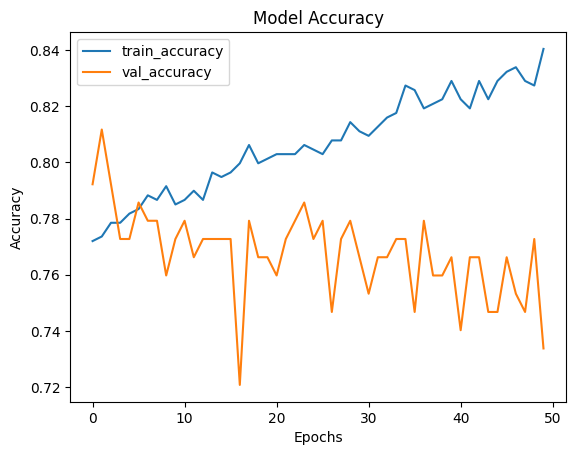

In [47]:
plt.plot(history.history['accuracy'], label = 'train_accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

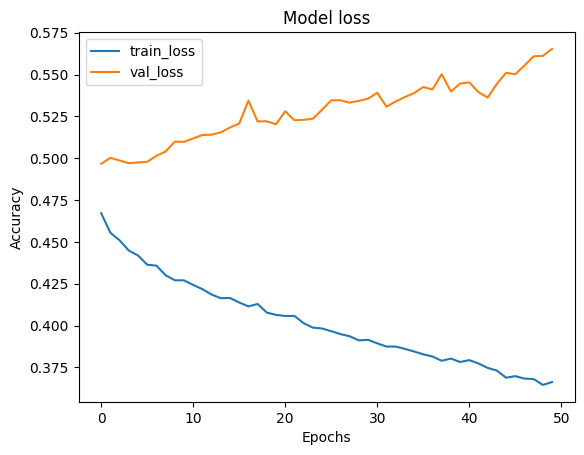

In [48]:
plt.plot(history.history['loss'], label = 'train_loss')
plt.plot(history.history['val_loss'], label = 'val_loss')

plt.title('Model loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()